# EEG Emotion Classifier

Questo notebook esegue la classificazione delle emozioni a partire da segnali EEG. In particolare:

- Carica e prepara il dataset separando le feature EEG dalla colonna target (emozione).
- Codifica le etichette delle emozioni in valori numerici e le converte in one-hot encoding.
- Divide il dataset in training e test set, standardizzando le feature EEG.
- Definisce e compila un modello di rete neurale feedforward con due layer densi e dropout per prevenire l'overfitting.
- Allena il modello utilizzando una callback di early stopping basata sulla validazione per evitare overfitting.
- Valuta le prestazioni sul test set.
- Salva il modello addestrato e lo scaler utilizzato per la standardizzazione.


## 0: Setup Iniziale e Importazione Librerie


In [27]:
# Installazione delle librerie

!pip install -q pandas numpy scikit-learn tensorflow Pillow scikit-fuzzy matplotlib seaborn
print("Librerie installate con successo!")

Librerie installate con successo!


In [28]:
# Accesso a Google Drive
from google.colab import drive

# Analisi e manipolazione dei dati
import pandas as pd
import numpy as np
import os

# Visualizzazione dei dati
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing e modellazione con Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

# Costruzione, addestramento e salvataggio di modelli con TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Logica fuzzy con SciKit-Fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Manipolazione di immagini
from PIL import Image, ImageDraw

# Operazioni casuali
import random


## 1: Collegemanto a Google Drive e Importazione File Necessari


In [29]:
# Monta Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Percorso al file nel Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/IA FROM ENGINEERING TO ARTS/ADDESTRAMENTO/dataset_mod.csv'

# Caricamento del dataset
df = pd.read_csv(file_path)
print("Dataset caricato con successo.\n")
df

Dataset caricato con successo.



,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.620,30.30,-356.0,15.6,26.3,1.070,0.411,-15.700,2.060,3.15,...,23.5,20.300,20.300,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.800,33.10,32.0,25.8,22.8,6.550,1.680,2.880,3.830,-4.82,...,-23.3,-21.800,-21.800,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.900,29.40,-416.0,16.7,23.7,79.900,3.360,90.200,89.900,2.03,...,462.0,-233.000,-233.000,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.900,31.60,-143.0,19.8,24.3,-0.584,-0.284,8.820,2.300,-1.97,...,299.0,-243.000,-243.000,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.300,31.30,45.2,27.3,24.5,34.800,-5.790,3.060,41.400,5.52,...,12.0,38.100,38.100,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,27.500,29.10,25.3,26.3,25.5,-0.926,0.306,0.251,-2.640,2.51,...,-29.3,29.000,29.000,-29.3,183.0,7.04,-48.80,-48.80,7.04,NEUTRAL
2126,-5.290,3.27,14.2,-15.5,16.6,1.260,-2.570,-9.130,3.330,-3.33,...,27.6,13.300,13.300,27.6,43.7,32.60,-11.30,-11.30,32.60,POSITIVE
2127,32.400,32.20,32.2,30.8,23.4,1.640,-2.030,0.647,-0.121,-1.10,...,-21.7,0.218,0.218,-21.7,95.2,-19.90,47.20,47.20,-19.90,NEUTRAL
2128,16.300,31.30,-284.0,14.3,23.9,4.200,1.090,4.460,4.720,6.63,...,594.0,-324.000,-324.000,594.0,-35.5,142.00,-59.80,-59.80,142.00,POSITIVE


## 2: Inizializzazione e Setup dell'Ambiente


In [31]:
# Colonna target (emozione)
emotion_col = 'label'

# Colonne EEG (tutte tranne la colonna target)
eeg_cols = [col for col in df.columns if col != emotion_col]

# Separazione delle feature e delle etichette
X = df[eeg_cols].values
y = df[emotion_col].values

print(f"\nColonna target: {emotion_col}")
print(f"\nNumero di feature EEG: {len(eeg_cols)}")
print(f"\nDimensione matrice feature X: {X.shape}")
print(f"\nDimensione vettore etichette y: {y.shape}")


Colonna target: label

Numero di feature EEG: 2548

Dimensione matrice feature X: (2130, 2548)

Dimensione vettore etichette y: (2130,)


## 3: Preparazione del Dataset e Pre-Elaborazione dei Dati



Classi di emozione rilevate: ['NEGATIVE' 'NEUTRAL' 'POSITIVE']



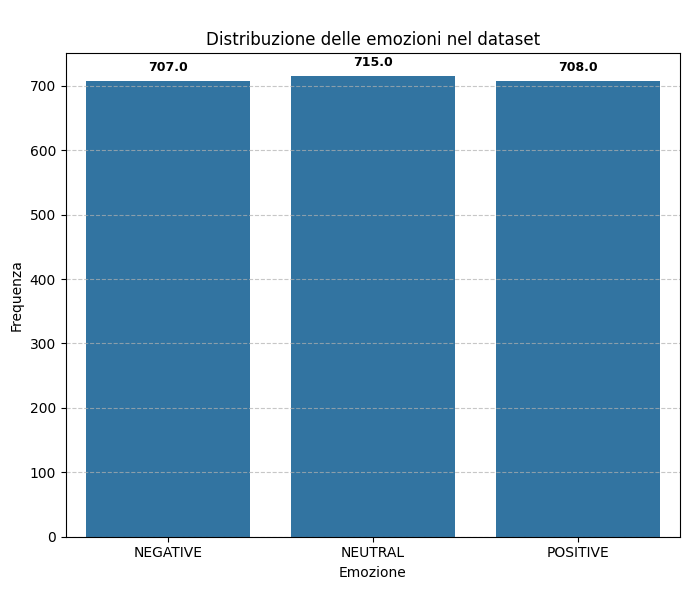


Dataset diviso in training e test set.

Feature EEG standardizzate.

Etichette codificate in one-hot encoding.

Scaler salvato con successo.


In [32]:
# Codifica delle etichette in interi
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
print(f"\nClassi di emozione rilevate: {label_encoder.classes_}\n")

# Distribuzione delle Emozioni
plt.figure(figsize=(7, 6))
ax = sns.countplot(x=y)
plt.title('\nDistribuzione delle emozioni nel dataset')
plt.xlabel('Emozione')
plt.ylabel('Frequenza')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Aggiunta delle etichette di frequenza sopra ogni barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Divisione in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=48)

# Standardizzazione delle feature EEG
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Salvataggio dello scaler
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/IA FROM ENGINEERING TO ARTS/INFERENZA/FILE DI SUPPORTO/scaler.pkl')

# Conversione delle etichette in one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print("\nDataset diviso in training e test set.")
print("\nFeature EEG standardizzate.")
print("\nEtichette codificate in one-hot encoding.")
print("\nScaler salvato con successo.")


## 4. Creazione del Modello di Classificazione Emotiva (Rete Neurale)
Definizione, addestramento e valutazione di un modello di rete neurale artificiale per la classificazione delle emozioni basata su Segnali EEG preprocessati . La rete è una MLP (Multi-Layer Perceptron) con due layer densi (Dense) e dropout per ridurre l’overfitting. Viene utilizzata la funzione di attivazione ReLU e una softmax finale per classificare in più classi.

Il modello è compilato con l’ottimizzatore Adam e la loss categoriale per problemi di classificazione multi-classe. Per evitare overfitting, viene applicato un callback di early stopping monitorando la validazione.

L’addestramento avviene con un’early stopping su un validation split del 20%. Al termine, il modello viene valutato sul test set e salvato.


In [33]:
# Definizione del modello di rete neurale
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compilazione del modello
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Riepilogo della rete
model.summary()

# Definizione callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Addestramento del modello con early stopping
history = model.fit(
    X_train_scaled, y_train_one_hot,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Valutazione sul test set
loss, accuracy = model.evaluate(X_test_scaled, y_test_one_hot, verbose=0)
print(f"\nLoss sul test set: {loss:.4f}")
print(f"Accuratezza sul test set: {accuracy * 100:.2f}%")

# Salvataggio del modello addestrato
model.save('/content/drive/MyDrive/Colab Notebooks/IA FROM ENGINEERING TO ARTS/INFERENZA/FILE DI SUPPORTO/emotion_classifier_model.keras')
print("\nModello salvato come 'emotion_classifier_model.keras'.")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       326,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,723 (1.28 MB)

 Trainable params: 334,723 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.5782 - loss: 0.9541 - val_accuracy: 0.8856 - val_loss: 0.3991
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7753 - loss: 0.5643 - val_accuracy: 0.9179 - val_loss: 0.2891
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8632 - loss: 0.4048 - val_accuracy: 0.9296 - val_loss: 0.2275
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8598 - loss: 0.3519 - val_accuracy: 0.9208 - val_loss: 0.2084
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9053 - loss: 0.2727 - val_accuracy: 0.9355 - val_loss: 0.1838
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9087 - loss: 0.2531 - val_accuracy: 0.9413 - val_loss: 0.1640
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9275 - loss: 0.2099 - val_accuracy: 0.9443 - val_loss: 0.1472
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9208 - loss: 0.2537 - val_accuracy: 0.9443 - val

## 4. Visualizzazione delle Metriche


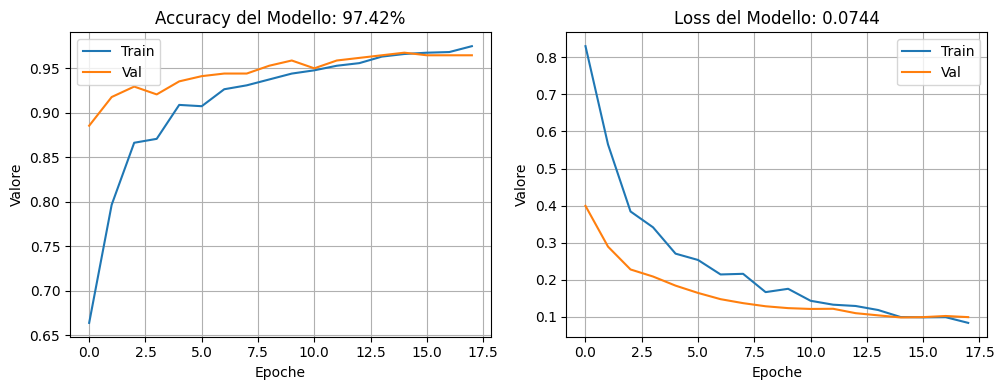

In [34]:
# Imposta dimensioni del canvas
plt.figure(figsize=(20, 4))

# -------- Accuracy --------
plt.subplot(1, 4, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title(f'Accuracy del Modello: {accuracy * 100:.2f}%')
plt.xlabel('Epoche')
plt.ylabel('Valore')
plt.legend()
plt.grid(True)

# -------- Loss --------
plt.subplot(1, 4, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title(f'Loss del Modello: {loss:.4f}')
plt.xlabel('Epoche')
plt.ylabel('Valore')
plt.legend()
plt.grid(True)


# Mostra tutti i grafici
plt.tight_layout()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


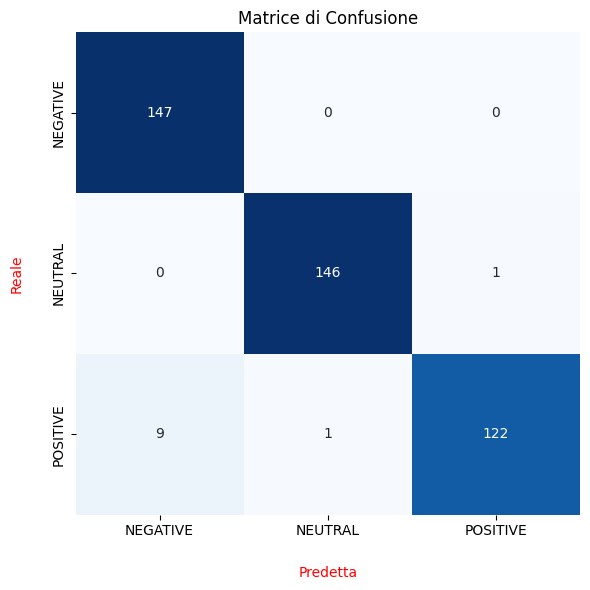


Classification Report:
----------------------
               precision    recall  f1-score   support

    NEGATIVE       0.94      1.00      0.97       147
     NEUTRAL       0.99      0.99      0.99       147
    POSITIVE       0.99      0.92      0.96       132

    accuracy                           0.97       426
   macro avg       0.98      0.97      0.97       426
weighted avg       0.98      0.97      0.97       426



In [35]:
# Nomi reali delle classi
class_names = label_encoder.classes_  # oppure ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

# Predizione delle probabilità
y_pred_prob = model.predict(X_test_scaled)

# Predizione delle classi
y_pred = np.argmax(y_pred_prob, axis=1)
y_test = np.argmax(y_test_one_hot, axis=1)

# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Report di classificazione
clr = classification_report(y_test, y_pred, target_names=class_names)

# Visualizzazione della matrice di confusione
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predetta", labelpad=20, color='red')  # Testo in rosso
plt.ylabel("Reale", labelpad=20, color='red')     # Testo in rosso
plt.title("Matrice di Confusione")
plt.tight_layout()
plt.show()

# Stampa del classification report
print("\nClassification Report:\n----------------------\n", clr)